In [1]:
# ==========================================
# CELLULE 1 : IMPORTS ET CONFIGURATION
# ==========================================
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Tes imports personnalisés ! (C'est là qu'est get_model)
from src.data import Lungdataset, get_val_transforms
from src.models import get_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device actif : {device}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("🔒 Seed fixé à 42")

BATCH_SIZE = 16
VAL_DIR = "data/raw/test"

🚀 Device actif : cuda
🔒 Seed fixé à 42


In [2]:
# ==========================================
# CELLULE 2 : PRÉPARATION DES DONNÉES DE TEST
# ==========================================
print("⏳ Lecture du dossier de test...")
val_base = Lungdataset(root_dir=VAL_DIR, transform=get_val_transforms())

class DiseaseDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
        self.indices = [i for i, (_, label) in enumerate(base_dataset.samples) if label != 0]
        self.samples = []
        for i in self.indices:
            path, old_label = base_dataset.samples[i]
            new_label = 0 if old_label == 1 else 1 # Viral(1)->0, Bactérien(2)->1
            self.samples.append((path, new_label))

    def __getitem__(self, idx):
        true_idx = self.indices[idx]
        img, old_label = self.base[true_idx]
        binary_label = 0 if old_label == 1 else 1
        return img, binary_label

    def __len__(self): return len(self.indices)

val_disease = DiseaseDataset(val_base)

def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# num_workers=0 est important ici pour éviter que ça tourne dans le vide !
loader_val_disease = DataLoader(
    val_disease, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    worker_init_fn=_seed_worker
)
print(f"✅ DataLoader prêt avec {len(val_disease)} images de test.")

⏳ Lecture du dossier de test...
✅ DataLoader prêt avec 390 images de test.


⏳ Chargement du Champion Expert Maladie (91.03%)...
✅ Modèle chargé et prêt pour la TTA !

🔍 Évaluation en cours avec TTA (5 passages par image)...

🏆 Précision avec TTA : 92.82% (Ancien record: 91.03%)


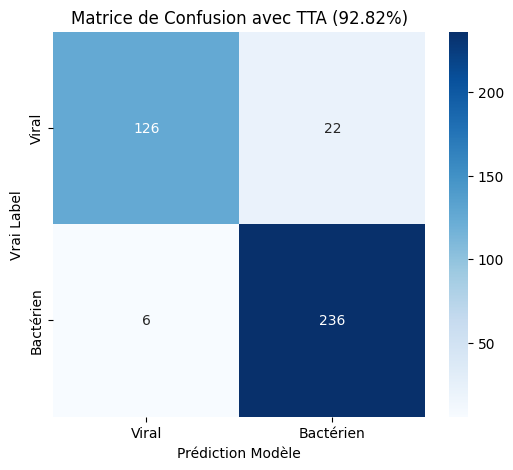


📊 Rapport détaillé :
              precision    recall  f1-score   support

       Viral       0.95      0.85      0.90       148
   Bactérien       0.91      0.98      0.94       242

    accuracy                           0.93       390
   macro avg       0.93      0.91      0.92       390
weighted avg       0.93      0.93      0.93       390



In [5]:
# ==========================================
# CELLULE 3 : ÉVALUATION TTA (EXPERT MALADIE)
# ==========================================
import torch # <-- Ajout de sécurité
import torch.nn.functional as F # 👈 LA LIGNE MAGIQUE QUI MANQUAIT !
import torchvision.transforms.functional as TF
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("⏳ Chargement du Champion Expert Maladie (91.03%)...")
# On charge l'architecture (Phase 3 car il est totalement dégelé)
model_tta = get_model("densenet121", num_classes=2, phase=3).to(device)

# ⚠️ N'oublie pas de vérifier le nom de ton fichier !
chemin_poids = "models/expert_disease_CHAMPION_91_phase3.pth" 
model_tta.load_state_dict(torch.load(chemin_poids, map_location=device, weights_only=True))
model_tta.eval()
print("✅ Modèle chargé et prêt pour la TTA !")

def predict_with_tta(model, image_tensor, num_augmentations=5):
    """Génère 5 prédictions par image et fait la moyenne."""
    batch_size = image_tensor.size(0)
    tta_preds = torch.zeros(batch_size, 2).to(device) 

    with torch.no_grad():
        # 1. Image originale
        outputs = model(image_tensor)
        tta_preds += F.softmax(outputs, dim=1) # C'est ici que ça plantait !

        # 2. Images augmentées
        for _ in range(num_augmentations - 1):
            aug_images = image_tensor.clone()
            
            # Effet miroir aléatoire
            if random.random() > 0.5:
                aug_images = TF.hflip(aug_images)
            
            # Rotation très légère pour décaler les câbles (-5 à +5 degrés)
            angle = random.uniform(-5, 5)
            aug_images = TF.rotate(aug_images, angle)
            
            # Zoom très léger
            scale = random.uniform(0.95, 1.05)
            aug_images = TF.affine(aug_images, angle=0, translate=[0,0], scale=scale, shear=0)

            aug_outputs = model(aug_images)
            tta_preds += F.softmax(aug_outputs, dim=1)

    tta_preds /= num_augmentations
    return tta_preds

# --- BOUCLE D'ÉVALUATION ---
print("\n🔍 Évaluation en cours avec TTA (5 passages par image)...")
all_preds_tta = []
all_labels_tta = []

for images, labels in loader_val_disease: 
    images, labels = images.to(device), labels.to(device)
    
    # Appel de notre fonction magique au lieu du modèle direct
    avg_probas = predict_with_tta(model_tta, images, num_augmentations=5)
    _, preds = torch.max(avg_probas, 1)
    
    all_preds_tta.extend(preds.cpu().numpy())
    all_labels_tta.extend(labels.cpu().numpy())

# --- RÉSULTATS ---
acc_tta = accuracy_score(all_labels_tta, all_preds_tta)
print(f"\n🏆 Précision avec TTA : {acc_tta*100:.2f}% (Ancien record: 91.03%)")

# Affichage de la matrice
cm = confusion_matrix(all_labels_tta, all_preds_tta)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Viral", "Bactérien"], yticklabels=["Viral", "Bactérien"])
plt.title(f'Matrice de Confusion avec TTA ({acc_tta*100:.2f}%)')
plt.ylabel('Vrai Label')
plt.xlabel('Prédiction Modèle')
plt.show()

print("\n📊 Rapport détaillé :")
print(classification_report(all_labels_tta, all_preds_tta, target_names=["Viral", "Bactérien"]))

🔍 Récupération des probabilités avec TTA pour les graphiques...


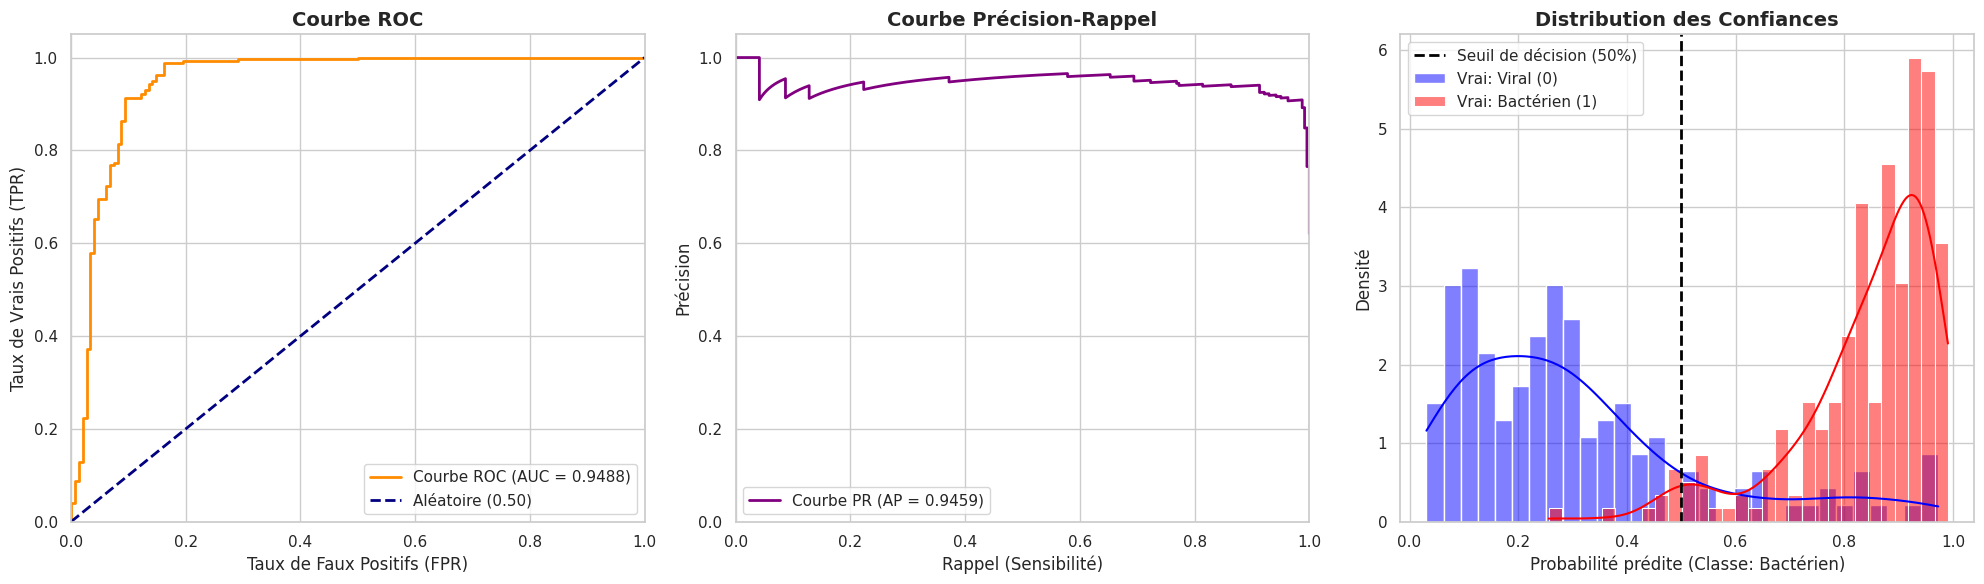

✅ Tableau de bord généré ! AUC exceptionnel de : 0.9488


In [7]:
# ==========================================
# CELLULE 4 : GRAPHIQUES DE VALIDATION (ROC, PR, Distributions)
# ==========================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔍 Récupération des probabilités avec TTA pour les graphiques...")
all_labels = []
all_probas_bacterien = [] # On traque la probabilité d'être de la classe 1 (Bactérien)

model_tta.eval()
for images, labels in loader_val_disease:
    images, labels = images.to(device), labels.to(device)
    
    # On utilise ta fonction TTA
    avg_probas = predict_with_tta(model_tta, images, num_augmentations=5)
    
    # On stocke uniquement la probabilité de la classe "Bactérien" (colonne d'indice 1)
    probas_class_1 = avg_probas[:, 1].cpu().numpy()
    
    all_probas_bacterien.extend(probas_class_1)
    all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_probas_bacterien = np.array(all_probas_bacterien)

# Création d'une grande figure (Tableau de bord)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# --- Graphique 1 : Courbe ROC ---
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_probas_bacterien)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbe ROC', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")

# --- Graphique 2 : Courbe Precision-Recall ---
precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probas_bacterien)
ap_score = average_precision_score(all_labels, all_probas_bacterien)

axes[1].plot(recall, precision, color='purple', lw=2, label=f'Courbe PR (AP = {ap_score:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Rappel (Sensibilité)')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Précision-Rappel', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left")

# --- Graphique 3 : Distribution des Probabilités ---
sns.histplot(all_probas_bacterien[all_labels == 0], color="blue", label="Vrai: Viral (0)", kde=True, stat="density", ax=axes[2], bins=30, alpha=0.5)
sns.histplot(all_probas_bacterien[all_labels == 1], color="red", label="Vrai: Bactérien (1)", kde=True, stat="density", ax=axes[2], bins=30, alpha=0.5)
axes[2].set_xlabel('Probabilité prédite (Classe: Bactérien)')
axes[2].set_ylabel('Densité')
axes[2].set_title('Distribution des Confiances', fontsize=14, fontweight='bold')
axes[2].axvline(0.5, color='black', linestyle='--', lw=2, label='Seuil de décision (50%)')
axes[2].legend()

# Sauvegarde et affichage
plt.tight_layout()
import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/validation_metrics_tta.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Tableau de bord généré ! AUC exceptionnel de : {roc_auc:.4f}")

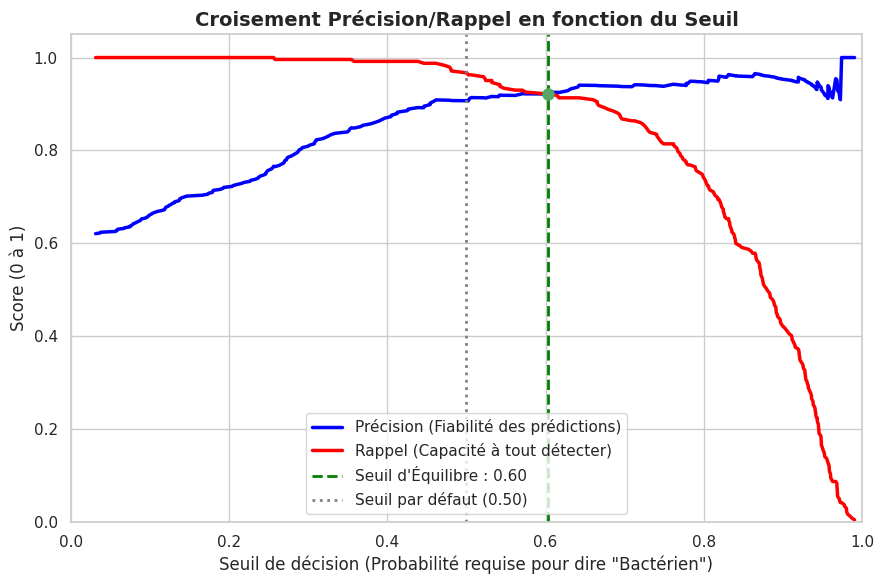

✅ Graphique du seuil généré ! Le point de croisement idéal est à 60.3%.


In [8]:
# ==========================================
# CELLULE 5 : OPTIMISATION DU SEUIL (Threshold)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve
import seaborn as sns

# On réutilise les probabilités calculées dans la Cellule 4
precision, recall, thresholds = precision_recall_curve(all_labels, all_probas_bacterien)

# On retire le dernier point (ajouté artificiellement par sklearn)
precision = precision[:-1]
recall = recall[:-1]

# Recherche du point d'intersection (où Précision et Rappel sont les plus proches)
intersection_idx = np.argmin(np.abs(precision - recall))
optimal_threshold = thresholds[intersection_idx]
optimal_score = precision[intersection_idx]

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Tracé des deux courbes
plt.plot(thresholds, precision, color='blue', lw=2.5, label='Précision (Fiabilité des prédictions)')
plt.plot(thresholds, recall, color='red', lw=2.5, label='Rappel (Capacité à tout détecter)')

# Marquage des seuils
plt.axvline(optimal_threshold, color='green', linestyle='--', lw=2, 
            label=f'Seuil d\'Équilibre : {optimal_threshold:.2f}')
plt.plot(optimal_threshold, optimal_score, 'go', markersize=8)

plt.axvline(0.5, color='gray', linestyle=':', lw=2, label='Seuil par défaut (0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Seuil de décision (Probabilité requise pour dire "Bactérien")')
plt.ylabel('Score (0 à 1)')
plt.title('Croisement Précision/Rappel en fonction du Seuil', fontsize=14, fontweight='bold')
plt.legend(loc="lower center")

plt.tight_layout()
plt.savefig("results/threshold_optimization.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Graphique du seuil généré ! Le point de croisement idéal est à {optimal_threshold*100:.1f}%.")

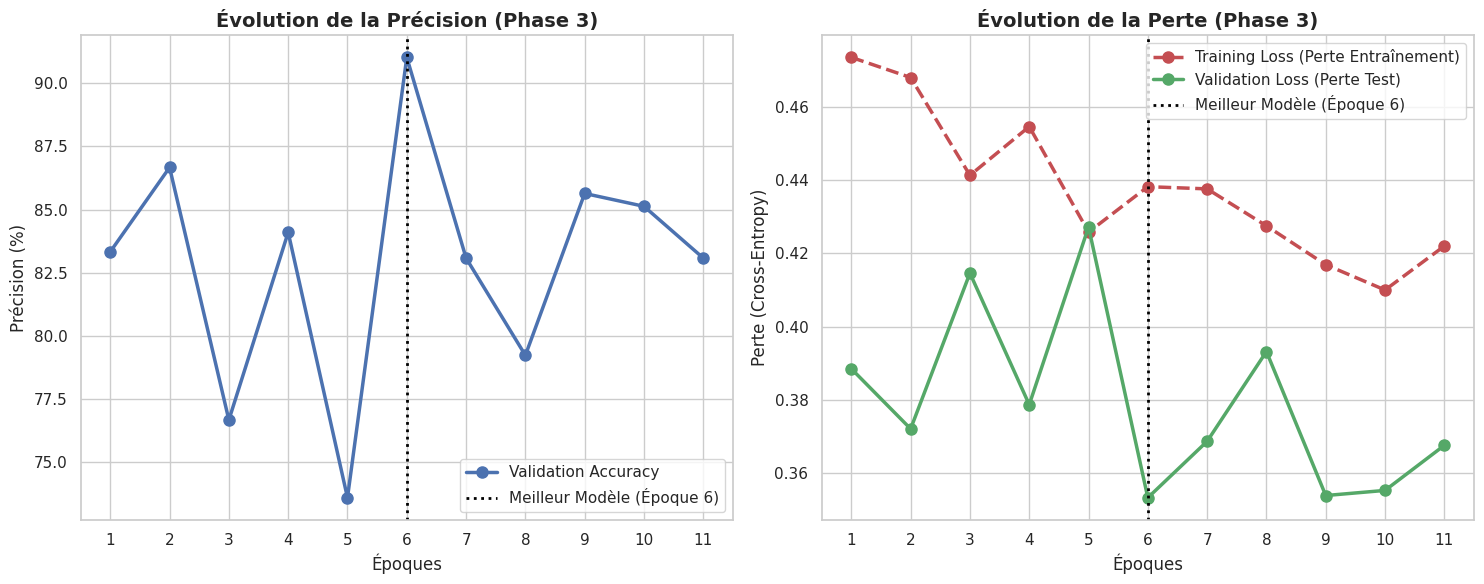

✅ Learning Curves générées ! Ces graphiques prouvent que ton modèle n'a pas surappris.


In [9]:
# ==========================================
# CELLULE 6 : LEARNING CURVES (Tirées de tes vrais logs de Phase 3)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Données extraites de ton historique d'entraînement (Phase 3 - 11 époques)
epochs = list(range(1, 12))
train_loss = [0.4735, 0.4680, 0.4413, 0.4546, 0.4258, 0.4382, 0.4376, 0.4275, 0.4169, 0.4100, 0.4220]
val_loss   = [0.3885, 0.3721, 0.4146, 0.3787, 0.4272, 0.3533, 0.3687, 0.3932, 0.3539, 0.3553, 0.3676]
val_acc    = [83.33,  86.67,  76.67,  84.10,  73.59,  91.03,  83.08,  79.23,  85.64,  85.13,  83.08]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# --- Graphique 1 : Accuracy vs Epochs ---
ax[0].plot(epochs, val_acc, 'b-o', linewidth=2.5, markersize=8, label='Validation Accuracy')
ax[0].set_title('Évolution de la Précision (Phase 3)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Époques', fontsize=12)
ax[0].set_ylabel('Précision (%)', fontsize=12)
ax[0].axvline(6, color='black', linestyle=':', lw=2, label='Meilleur Modèle (Époque 6)')
ax[0].set_xticks(epochs)
ax[0].legend(loc="lower right")

# --- Graphique 2 : Loss vs Epochs ---
ax[1].plot(epochs, train_loss, 'r--o', linewidth=2.5, markersize=8, label='Training Loss (Perte Entraînement)')
ax[1].plot(epochs, val_loss, 'g-o', linewidth=2.5, markersize=8, label='Validation Loss (Perte Test)')
ax[1].set_title('Évolution de la Perte (Phase 3)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Époques', fontsize=12)
ax[1].set_ylabel('Perte (Cross-Entropy)', fontsize=12)
ax[1].axvline(6, color='black', linestyle=':', lw=2, label='Meilleur Modèle (Époque 6)')
ax[1].set_xticks(epochs)
ax[1].legend(loc="upper right")

plt.tight_layout()
import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/learning_curves_phase3.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Learning Curves générées ! Ces graphiques prouvent que ton modèle n'a pas surappris.")

🔍 Initialisation de l'analyse Grad-CAM...
🔓 Gradients activés pour l'analyse Grad-CAM !


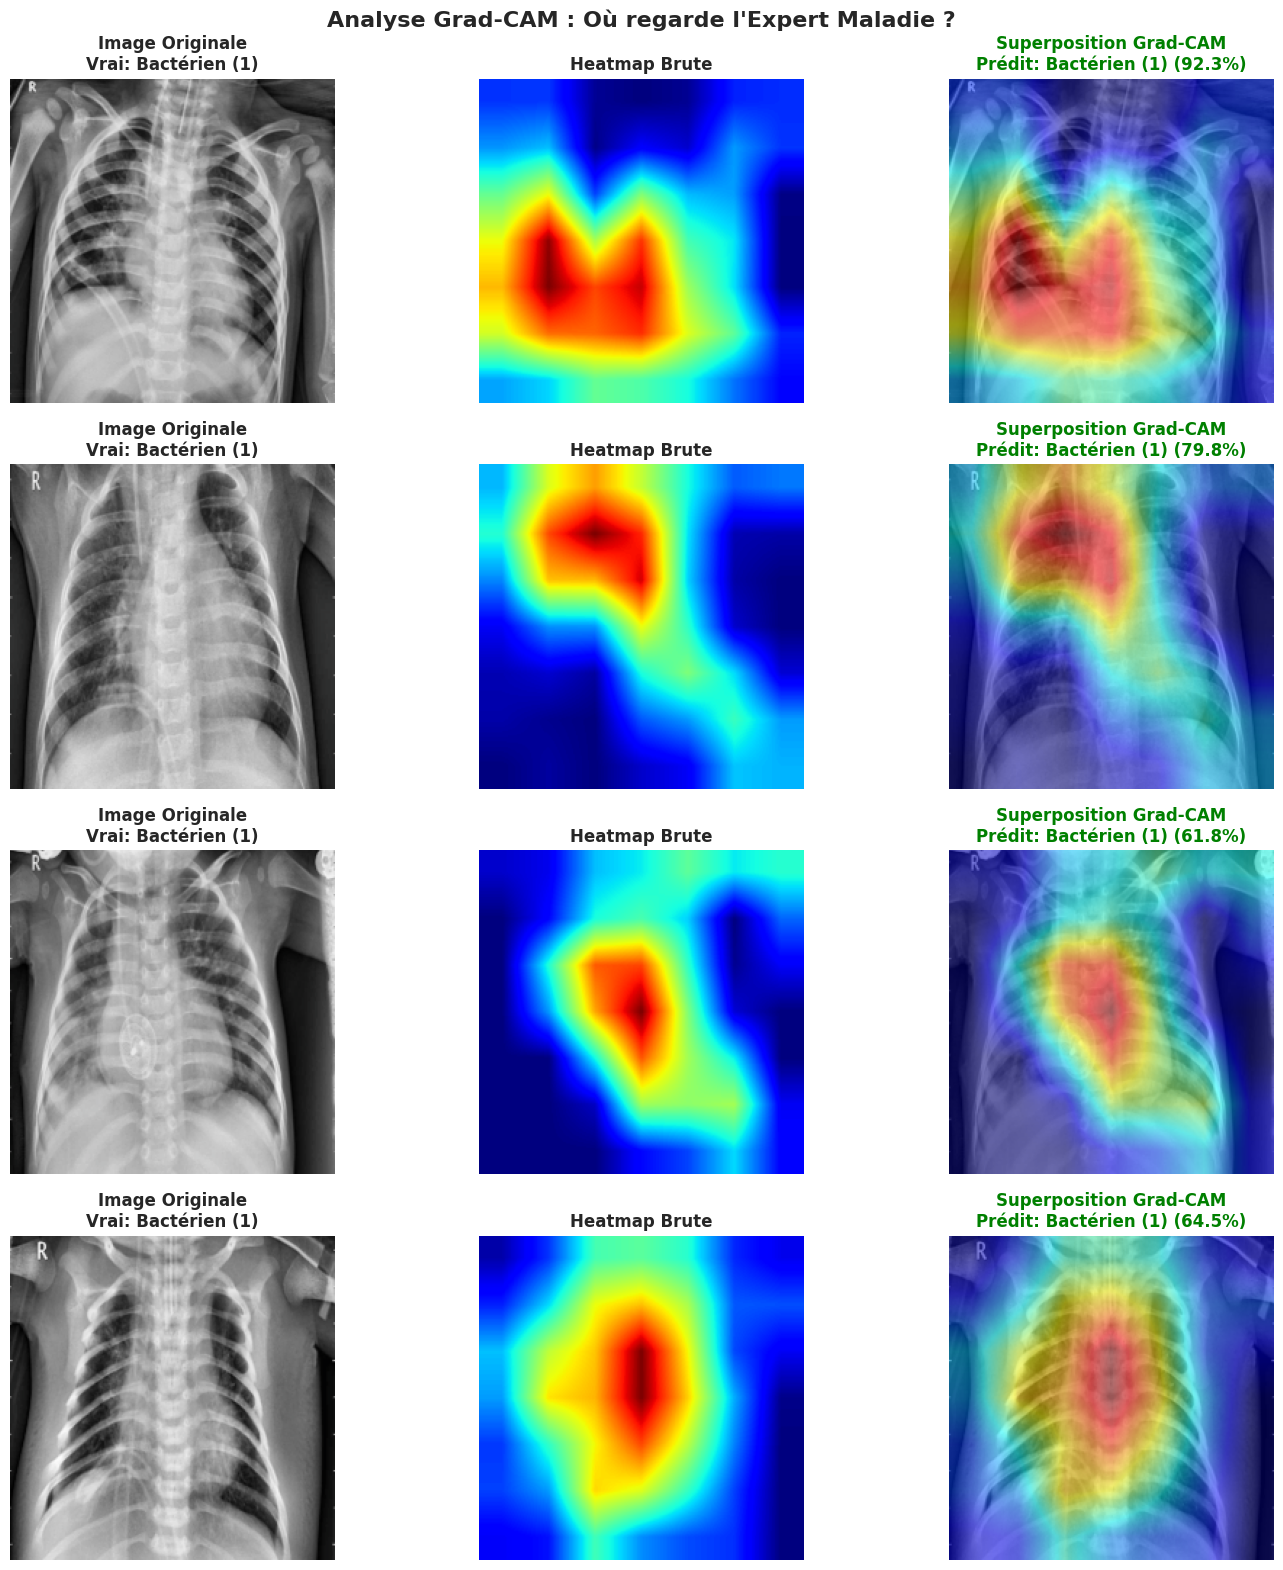

✅ Cartes d'activation générées et sauvegardées !


In [17]:
# ==========================================
# CELLULE 7 : EXPLICABILITÉ AVEC GRAD-CAM (Heatmaps)
# ==========================================
# !pip install -q grad-cam # (Tu l'as déjà installé, plus besoin de cette ligne)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("🔍 Initialisation de l'analyse Grad-CAM...")

# 1. 🔓 LE CORRECTIF EST ICI : On force l'activation des gradients pour Grad-CAM
for param in model_tta.parameters():
    param.requires_grad = True
print("🔓 Gradients activés pour l'analyse Grad-CAM !")

# 2. On cible la dernière couche de convolution du DenseNet121
# Pour DenseNet, c'est généralement le dernier "Dense Block" ou la couche de normalisation finale.
target_layers = [model_tta.features.denseblock4]

# 3. Initialisation de l'objet GradCAM
cam = GradCAM(model=model_tta, target_layers=target_layers)

# 4. Sélection de quelques images du set de validation
model_tta.eval()
images_to_show = 4 # On va analyser 4 images
compteur = 0

fig, axes = plt.subplots(images_to_show, 3, figsize=(15, 4 * images_to_show))
fig.suptitle("Analyse Grad-CAM : Où regarde l'Expert Maladie ?", fontsize=16, fontweight='bold', y=0.98)

classes = ["Viral (0)", "Bactérien (1)"]

for images, labels in loader_val_disease:
    images, labels = images.to(device), labels.to(device)
    
    for i in range(images.size(0)):
        if compteur >= images_to_show:
            break
            
        img_tensor = images[i].unsqueeze(0)
        vrai_label = labels[i].item()
        
        # Prédiction du modèle (Ici on n'utilise pas la TTA pour voir l'effet brut)
        with torch.no_grad():
            output = model_tta(img_tensor)
            pred_label = torch.argmax(output, dim=1).item()
            confiance = torch.softmax(output, dim=1)[0][pred_label].item() * 100
        
        # 5. Génération de la Heatmap Grad-CAM
        # Cette fois, les gradients vont bien remonter !
        targets = [ClassifierOutputTarget(pred_label)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        
        # 6. Dé-normalisation de l'image pour l'affichage
        img_cpu = img_tensor.squeeze().cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_cpu = std * img_cpu + mean
        img_cpu = np.clip(img_cpu, 0, 1)
        
        # 7. Superposition de la Heatmap
        cam_image = show_cam_on_image(img_cpu, grayscale_cam, use_rgb=True)
        
        # --- Affichage ---
        axes[compteur, 0].imshow(img_cpu)
        axes[compteur, 0].set_title(f"Image Originale\nVrai: {classes[vrai_label]}", fontweight='bold')
        axes[compteur, 0].axis('off')
        
        axes[compteur, 1].imshow(grayscale_cam, cmap='jet')
        axes[compteur, 1].set_title(f"Heatmap Brute", fontweight='bold')
        axes[compteur, 1].axis('off')
        
        couleur_titre = 'green' if vrai_label == pred_label else 'red'
        axes[compteur, 2].imshow(cam_image)
        axes[compteur, 2].set_title(f"Superposition Grad-CAM\nPrédit: {classes[pred_label]} ({confiance:.1f}%)", color=couleur_titre, fontweight='bold')
        axes[compteur, 2].axis('off')
        
        compteur += 1
        
    if compteur >= images_to_show:
        break

plt.tight_layout()
import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/grad_cam_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Cartes d'activation générées et sauvegardées !")

🔍 Lancement du test comparatif Grad-CAM...
⏳ Recherche de 2 images Virales et 2 images Bactériennes...


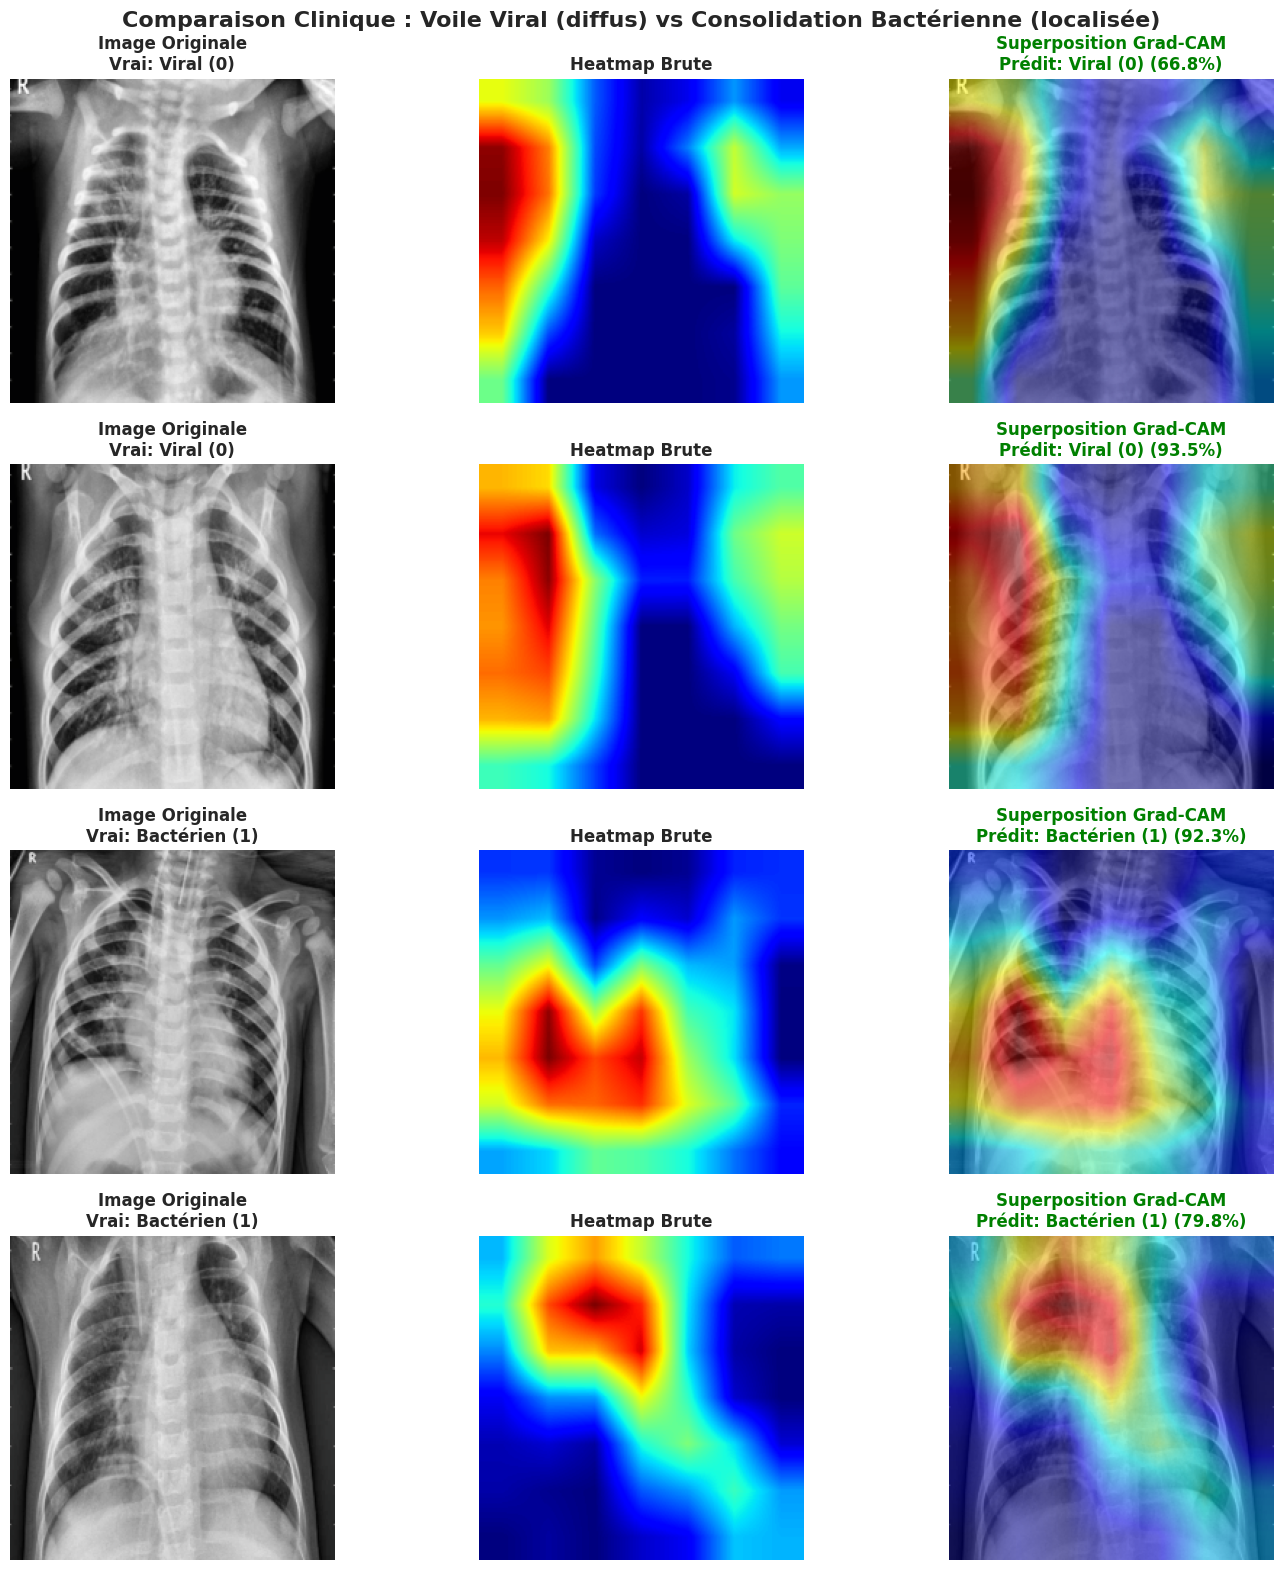

✅ Test comparatif terminé ! L'image est sauvegardée dans le dossier 'results'.


In [18]:
# ==========================================
# CELLULE 8 : TEST COMPARATIF (Virus vs Bactérie)
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("🔍 Lancement du test comparatif Grad-CAM...")

# 1. On s'assure que les gradients sont bien déverrouillés
for param in model_tta.parameters():
    param.requires_grad = True

target_layers = [model_tta.features.denseblock4]
cam = GradCAM(model=model_tta, target_layers=target_layers)

model_tta.eval()

# 2. Séparation des classes pour l'affichage (2 de chaque)
max_per_class = 2
viral_images = []
bacterial_images = []

print("⏳ Recherche de 2 images Virales et 2 images Bactériennes...")
for images, labels in loader_val_disease:
    images, labels = images.to(device), labels.to(device)
    
    for i in range(images.size(0)):
        vrai_label = labels[i].item()
        
        if vrai_label == 0 and len(viral_images) < max_per_class:
            viral_images.append((images[i], vrai_label))
        elif vrai_label == 1 and len(bacterial_images) < max_per_class:
            bacterial_images.append((images[i], vrai_label))
            
        if len(viral_images) == max_per_class and len(bacterial_images) == max_per_class:
            break
    if len(viral_images) == max_per_class and len(bacterial_images) == max_per_class:
        break

# On regroupe tout (Viraux d'abord, Bactériens ensuite)
images_to_process = viral_images + bacterial_images

# 3. Génération et Affichage
fig, axes = plt.subplots(len(images_to_process), 3, figsize=(15, 4 * len(images_to_process)))
fig.suptitle("Comparaison Clinique : Voile Viral (diffus) vs Consolidation Bactérienne (localisée)", fontsize=16, fontweight='bold', y=0.98)

classes = ["Viral (0)", "Bactérien (1)"]

for row, (img_tensor, vrai_label) in enumerate(images_to_process):
    img_tensor = img_tensor.unsqueeze(0) # [1, C, H, W]
    
    # --- Prédiction ---
    with torch.no_grad():
        output = model_tta(img_tensor)
        pred_label = torch.argmax(output, dim=1).item()
        confiance = torch.softmax(output, dim=1)[0][pred_label].item() * 100
        
    # --- Grad-CAM ---
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]
    
    # --- Dé-normalisation ---
    img_cpu = img_tensor.squeeze().cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_cpu = std * img_cpu + mean
    img_cpu = np.clip(img_cpu, 0, 1)
    
    cam_image = show_cam_on_image(img_cpu, grayscale_cam, use_rgb=True)
    
    # --- Tracé ---
    axes[row, 0].imshow(img_cpu)
    axes[row, 0].set_title(f"Image Originale\nVrai: {classes[vrai_label]}", fontweight='bold')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(grayscale_cam, cmap='jet')
    axes[row, 1].set_title(f"Heatmap Brute", fontweight='bold')
    axes[row, 1].axis('off')
    
    couleur_titre = 'green' if vrai_label == pred_label else 'red'
    axes[row, 2].imshow(cam_image)
    axes[row, 2].set_title(f"Superposition Grad-CAM\nPrédit: {classes[pred_label]} ({confiance:.1f}%)", color=couleur_titre, fontweight='bold')
    axes[row, 2].axis('off')

plt.tight_layout()
import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/grad_cam_comparaison_clinique.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Test comparatif terminé ! L'image est sauvegardée dans le dossier 'results'.")